# UAV Landing Safety Assessment — KNN Classifier

**Objective:** Given a post-disaster satellite image, determine whether the depicted area is **safe**, a **caution zone**, or **unsafe** for UAV landing.

**Unit of analysis:** One image = one candidate landing zone.

**Safety labels** are derived from the existing building-damage annotations using the same expert-defined risk heuristic as the SVM notebook.

---
| Class | Meaning | Heuristic basis |
|---|---|---|
| **Safe** | Area is structurally intact; landing is feasible | ≥70 % no-damage buildings AND low-risk disaster type AND <10 % destroyed |
| **Caution** | Partial damage or environmental hazard; proceed with care | Intermediate damage mix OR moderate-risk disaster |
| **Unsafe** | Active hazard or heavy structural collapse; do not land | ≥30 % destroyed/major-damage OR high-risk disaster type (flood, tsunami, volcano, earthquake) |

## 1. Setup & Imports

In [1]:
import os, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from shapely import wkt as shapely_wkt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)

BASE_DIR  = Path(r'd:\ENGG2112Project\ClearedSet\post_disaster_split')
IMG_DIR   = BASE_DIR / 'images'
LABEL_DIR = BASE_DIR / 'labels'

print('Images :', len(list(IMG_DIR.glob('*.png'))))
print('Labels :', len(list(LABEL_DIR.glob('*.json'))))

Images : 1866
Labels : 1866


## 2. Disaster Risk Taxonomy

Each disaster event is assigned a **risk tier** (1–3) reflecting its inherent UAV-landing hazard:

| Tier | Meaning | Events |
|---|---|---|
| 1 – Low | Fire/smoke risk; ground mostly navigable | socal-fire, santa-rosa-wildfire |
| 2 – Moderate | Wind debris, partial flooding | hurricane-matthew, hurricane-michael |
| 3 – High | Water saturation, debris fields, ground instability | hurricane-florence, hurricane-harvey, midwest-flooding, palu-tsunami, mexico-earthquake, guatemala-volcano |

In [2]:
DISASTER_RISK = {
    'socal-fire'         : (1, 'Wildfire',          'smoke / ash'),
    'santa-rosa-wildfire': (1, 'Wildfire',          'smoke / ash'),
    'hurricane-matthew'  : (2, 'Hurricane',         'wind debris'),
    'hurricane-michael'  : (2, 'Hurricane',         'wind debris'),
    'hurricane-florence' : (3, 'Hurricane+Flooding','water / mud'),
    'hurricane-harvey'   : (3, 'Hurricane+Flooding','water / mud'),
    'midwest-flooding'   : (3, 'Flooding',          'water / mud'),
    'palu-tsunami'       : (3, 'Tsunami',           'water / debris'),
    'mexico-earthquake'  : (3, 'Earthquake',        'rubble / instability'),
    'guatemala-volcano'  : (3, 'Volcanic Eruption', 'ash / heat'),
}

SAFETY_LABELS = {0: 'Safe', 1: 'Caution', 2: 'Unsafe'}
SAFETY_COLORS = {0: '#4CAF50', 1: '#FFC107', 2: '#F44336'}
DAMAGE_ORDER  = ['no-damage', 'minor-damage', 'major-damage', 'destroyed']

## 3. Feature Extraction — Image Level

Features serve two distinct roles — **label derivation** and **KNN input**. Mixing them causes data leakage.

### Used to DERIVE the safety label only (never fed to KNN)
- `pct_no_damage`, `pct_severe`, `pct_destroyed` etc. — damage class proportions
- `risk_tier` — disaster-type hazard tier (1–3)

### KNN input features (observable from sensor data alone)

**Building geometry** (count and footprint size — *not* damage class)
- `n_buildings`, `mean_building_area`, `std_building_area`

**Environmental / visual features** (from image pixels)
- `mean_R/G/B`, `std_R/G/B`, `blue_dominance`, `brightness`, `texture_roughness`, `dark_fraction`

**Sensor / acquisition metadata**
- `gsd`, `off_nadir_angle`, `sun_elevation`

In [3]:
def shannon_entropy(counts):
    total = counts.sum()
    if total == 0:
        return 0.0
    probs = counts / total
    probs = probs[probs > 0]
    return float(-np.sum(probs * np.log2(probs)))


def image_visual_features(img_path: str, resize_to: int = 256) -> dict:
    img  = Image.open(img_path).convert('RGB').resize((resize_to, resize_to), Image.BILINEAR)
    arr  = np.array(img, dtype=np.float32) / 255.0
    r, g, b = arr[:,:,0], arr[:,:,1], arr[:,:,2]
    grey = arr.mean(axis=2)
    gy = np.diff(grey, axis=0)[:, :-1]
    gx = np.diff(grey, axis=1)[:-1, :]
    grad_mag = np.sqrt(gx**2 + gy**2)
    return {
        'mean_R'           : float(r.mean()),
        'mean_G'           : float(g.mean()),
        'mean_B'           : float(b.mean()),
        'std_R'            : float(r.std()),
        'std_G'            : float(g.std()),
        'std_B'            : float(b.std()),
        'blue_dominance'   : float(b.mean() - r.mean()),
        'brightness'       : float(grey.mean()),
        'texture_roughness': float(grad_mag.mean()),
        'dark_fraction'    : float((grey < 0.15).mean()),
    }


def extract_image_record(json_path: Path, img_dir: Path) -> dict | None:
    with open(json_path) as f:
        data = json.load(f)

    meta    = data.get('metadata', {})
    xy_list = data.get('features', {}).get('xy', [])
    img_name = meta.get('img_name', json_path.stem + '.png')
    img_path = img_dir / img_name
    if not img_path.exists():
        return None

    dmg_counts = {d: 0 for d in DAMAGE_ORDER}
    building_areas = []

    for feat in xy_list:
        props   = feat.get('properties', {})
        subtype = props.get('subtype', '').strip()
        if subtype not in dmg_counts:
            continue
        dmg_counts[subtype] += 1
        try:
            geom = shapely_wkt.loads(feat.get('wkt', ''))
            if not geom.is_empty:
                b = geom.bounds
                building_areas.append((b[2]-b[0]) * (b[3]-b[1]))
        except Exception:
            pass

    n_total   = max(sum(dmg_counts.values()), 1)
    cnts_arr  = np.array([dmg_counts[d] for d in DAMAGE_ORDER], dtype=float)
    pct_no_damage = dmg_counts['no-damage']   / n_total
    pct_major     = dmg_counts['major-damage']/ n_total
    pct_destroyed = dmg_counts['destroyed']   / n_total
    pct_severe    = pct_major + pct_destroyed

    disaster = meta.get('disaster', 'unknown')
    risk_tier, risk_label, primary_hazard = DISASTER_RISK.get(
        disaster, (2, 'Unknown', 'unknown hazard')
    )

    if pct_severe >= 0.30 or risk_tier == 3:
        safety = 2
    elif pct_no_damage >= 0.70 and risk_tier == 1 and pct_destroyed < 0.10:
        safety = 0
    else:
        safety = 1

    vis = image_visual_features(str(img_path))

    return {
        'img_name'          : img_name,
        'disaster'          : disaster,
        'n_buildings'       : n_total,
        'mean_building_area': float(np.mean(building_areas)) if building_areas else 0.0,
        'std_building_area' : float(np.std(building_areas))  if building_areas else 0.0,
        'gsd'               : float(meta.get('gsd', 0)),
        'off_nadir_angle'   : float(meta.get('off_nadir_angle', 0)),
        'sun_elevation'     : float(meta.get('sun_elevation', 0)),
        # kept for EDA / reporting only
        'pct_severe'        : pct_severe,
        'safety_label'      : safety,
        **vis,
    }


print('Function definitions ready.')

Function definitions ready.


In [4]:
print('Parsing all label files …')
records = []
json_files = sorted(LABEL_DIR.glob('*.json'))

for i, jf in enumerate(json_files):
    rec = extract_image_record(jf, IMG_DIR)
    if rec is not None:
        records.append(rec)
    if (i + 1) % 300 == 0:
        print(f'  … {i+1}/{len(json_files)} done')

df = pd.DataFrame(records)
print(f'\nTotal images parsed: {len(df)}')
print(df['safety_label'].map(SAFETY_LABELS).value_counts())

Parsing all label files …
  … 300/1866 done
  … 600/1866 done
  … 900/1866 done
  … 1200/1866 done
  … 1500/1866 done
  … 1800/1866 done

Total images parsed: 1866
safety_label
Unsafe     1069
Caution     589
Safe        208
Name: count, dtype: int64


## 4. Exploratory Data Analysis

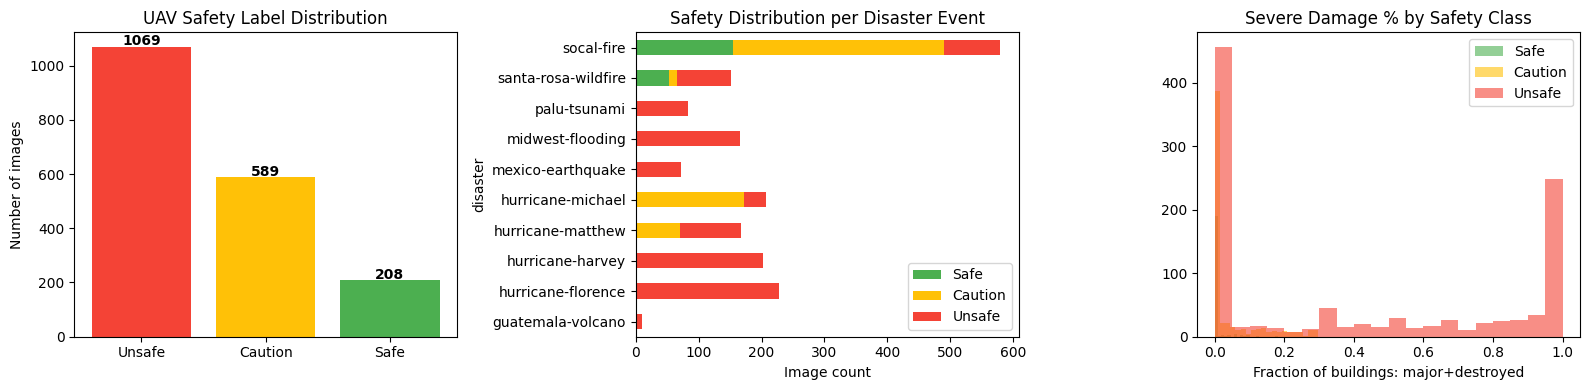

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 4a – Safety class distribution
counts = df['safety_label'].map(SAFETY_LABELS).value_counts()
colors = [SAFETY_COLORS[{v: k for k, v in SAFETY_LABELS.items()}[c]] for c in counts.index]
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('UAV Safety Label Distribution')
axes[0].set_ylabel('Number of images')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 4b – Safety class per disaster event
pivot = df.groupby(['disaster', 'safety_label']).size().unstack(fill_value=0)
pivot.columns = [SAFETY_LABELS[c] for c in pivot.columns]
pivot.plot(kind='barh', stacked=True, ax=axes[1],
           color=[SAFETY_COLORS[k] for k in SAFETY_LABELS], legend=True)
axes[1].set_title('Safety Distribution per Disaster Event')
axes[1].set_xlabel('Image count')
axes[1].legend(loc='lower right')

# 4c – Severe damage % by safety class
for label_id, label_name in SAFETY_LABELS.items():
    subset = df[df['safety_label'] == label_id]['pct_severe']
    axes[2].hist(subset, bins=20, alpha=0.6, label=label_name,
                 color=SAFETY_COLORS[label_id])
axes[2].set_title('Severe Damage % by Safety Class')
axes[2].set_xlabel('Fraction of buildings: major+destroyed')
axes[2].legend()

plt.tight_layout()
plt.show()

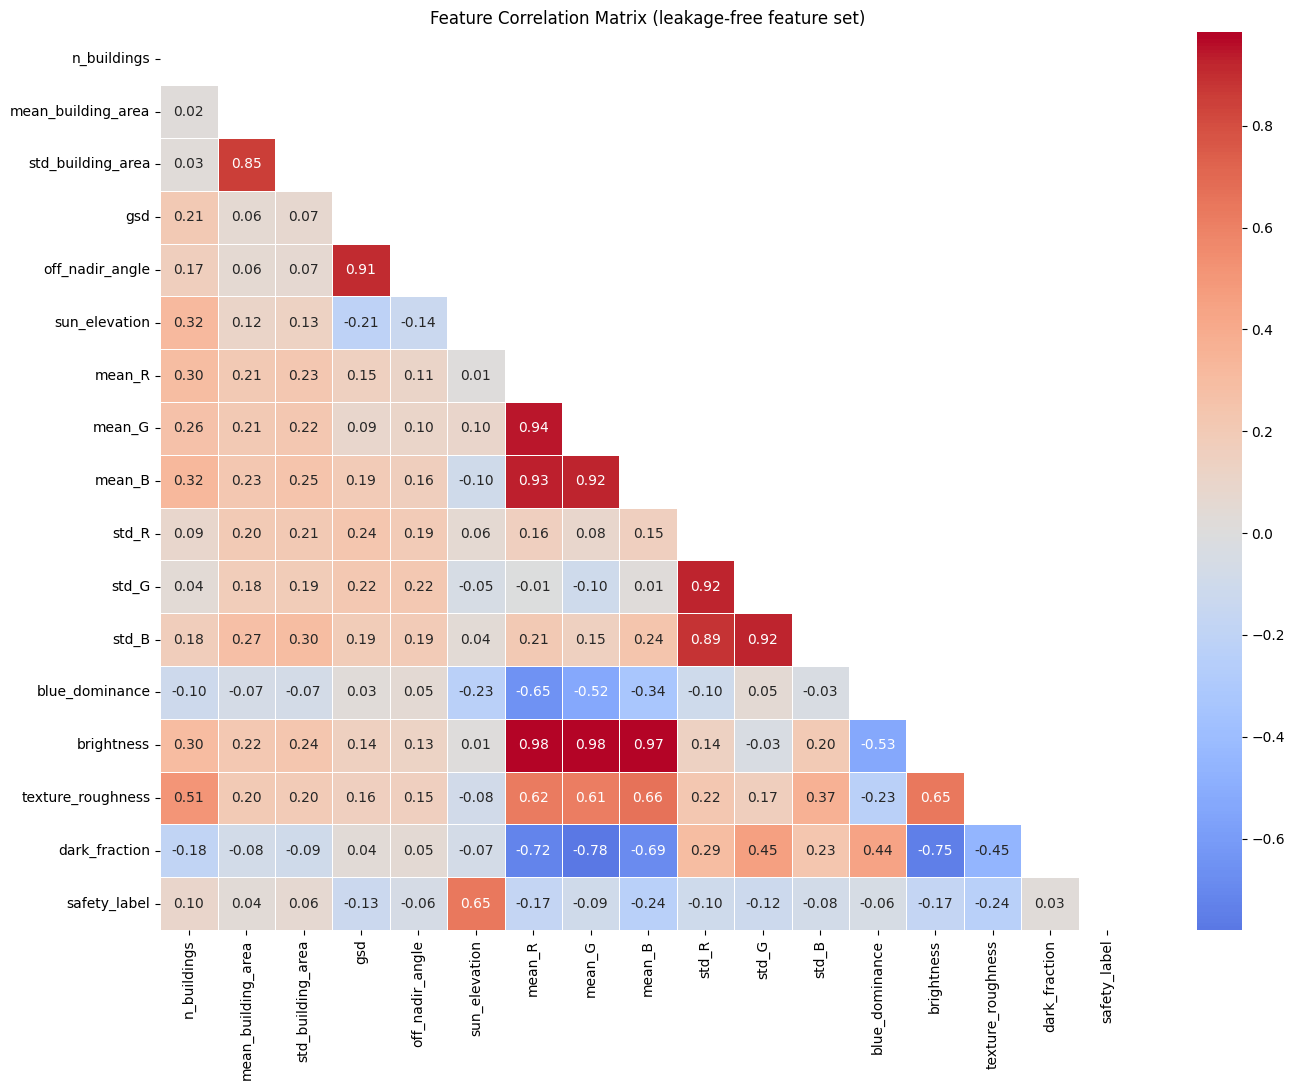


Feature correlations with safety_label:
sun_elevation         0.645023
texture_roughness     0.241809
mean_B                0.239620
mean_R                0.172243
brightness            0.169895
gsd                   0.126582
std_G                 0.115534
std_R                 0.100402
n_buildings           0.099558
mean_G                0.091218
std_B                 0.082340
std_building_area     0.063622
off_nadir_angle       0.058220
blue_dominance        0.055946
mean_building_area    0.038701
dark_fraction         0.026889


In [6]:
FEATURE_COLS = [
    'n_buildings', 'mean_building_area', 'std_building_area',
    'gsd', 'off_nadir_angle', 'sun_elevation',
    'mean_R', 'mean_G', 'mean_B',
    'std_R',  'std_G',  'std_B',
    'blue_dominance', 'brightness', 'texture_roughness', 'dark_fraction',
]

fig, ax = plt.subplots(figsize=(14, 11))
corr = df[FEATURE_COLS + ['safety_label']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.4, ax=ax)
ax.set_title('Feature Correlation Matrix (leakage-free feature set)')
plt.tight_layout()
plt.show()

print('\nFeature correlations with safety_label:')
print(corr['safety_label'].drop('safety_label').abs().sort_values(ascending=False).to_string())

## 5. Train / Test Split

In [7]:
X = df[FEATURE_COLS].values.astype(np.float32)
y = df['safety_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# KNN is distance-based — scaling is mandatory
scaler  = StandardScaler().fit(X_train)
X_tr_s  = scaler.transform(X_train)
X_te_s  = scaler.transform(X_test)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print('Train label distribution:', pd.Series(y_train).map(SAFETY_LABELS).value_counts().to_dict())
print('Test  label distribution:', pd.Series(y_test ).map(SAFETY_LABELS).value_counts().to_dict())

Train: (1492, 16)  |  Test: (374, 16)
Train label distribution: {'Unsafe': 855, 'Caution': 471, 'Safe': 166}
Test  label distribution: {'Unsafe': 214, 'Caution': 118, 'Safe': 42}


## 6. KNN Model Training

KNN is a **lazy learner** — it stores the training set and classifies new points by majority vote among the *k* nearest neighbours. There is no gradient-descent training phase.

We grid-search over:
- `n_neighbors` — number of neighbours to consider
- `weights` — `uniform` (equal vote) vs `distance` (closer neighbours vote more)
- `metric` — distance function: Euclidean, Manhattan, or Minkowski (p=3)

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan', 'minkowski'],
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
)

print('Running grid search …')
grid_search.fit(X_tr_s, y_train)

best_knn = grid_search.best_estimator_
print('\nBest parameters :', grid_search.best_params_)
print('Best CV F1      :', round(grid_search.best_score_, 4))

Running grid search …
Fitting 5 folds for each of 42 candidates, totalling 210 fits

Best parameters : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best CV F1      : 0.8473


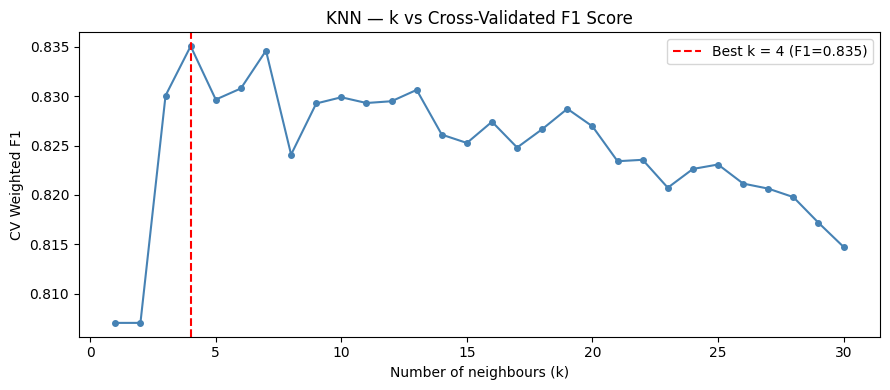

In [9]:
# K vs weighted F1 score curve (uniform weights, euclidean, to show trend)
k_range = range(1, 31)
f1_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
    scores = cross_val_score(knn, X_tr_s, y_train, cv=cv, scoring='f1_weighted')
    f1_scores.append(scores.mean())

best_k_idx = int(np.argmax(f1_scores))

plt.figure(figsize=(9, 4))
plt.plot(k_range, f1_scores, marker='o', markersize=4, color='steelblue')
plt.axvline(k_range[best_k_idx], color='red', linestyle='--',
            label=f'Best k = {k_range[best_k_idx]} (F1={f1_scores[best_k_idx]:.3f})')
plt.xlabel('Number of neighbours (k)')
plt.ylabel('CV Weighted F1')
plt.title('KNN — k vs Cross-Validated F1 Score')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Top grid-search results
cv_results = pd.DataFrame(grid_search.cv_results_)
top = (
    cv_results[['param_n_neighbors', 'param_weights', 'param_metric',
                'mean_test_score', 'std_test_score']]
    .sort_values('mean_test_score', ascending=False)
    .head(10)
)
top.columns = ['k', 'weights', 'metric', 'mean_F1', 'std_F1']
top['mean_F1'] = top['mean_F1'].round(4)
top['std_F1']  = top['std_F1'].round(4)
top

,k,weights,metric,mean_F1,std_F1
15,3,distance,manhattan,0.8473,0.0157
14,3,uniform,manhattan,0.8449,0.0141
16,5,uniform,manhattan,0.8444,0.0120
17,5,distance,manhattan,0.8444,0.0159
19,7,distance,manhattan,0.8437,0.0152
21,9,distance,manhattan,0.8414,0.0159
18,7,uniform,manhattan,0.8406,0.0150
25,15,distance,manhattan,0.8375,0.0103
5,7,distance,euclidean,0.8346,0.0144
33,7,distance,minkowski,0.8346,0.0144


## 7. Evaluation

In [11]:
y_pred = best_knn.predict(X_te_s)
present = sorted(np.unique(np.concatenate([y_test, y_pred])))

sep = '=' * 55
print(sep)
print('  KNN Classifier')
print(sep)
print(classification_report(
    y_test, y_pred,
    labels=present,
    target_names=[SAFETY_LABELS[i] for i in present]
))

  KNN Classifier
              precision    recall  f1-score   support

        Safe       0.68      0.55      0.61        42
     Caution       0.77      0.85      0.81       118
      Unsafe       0.91      0.90      0.91       214

    accuracy                           0.84       374
   macro avg       0.79      0.76      0.77       374
weighted avg       0.84      0.84      0.84       374



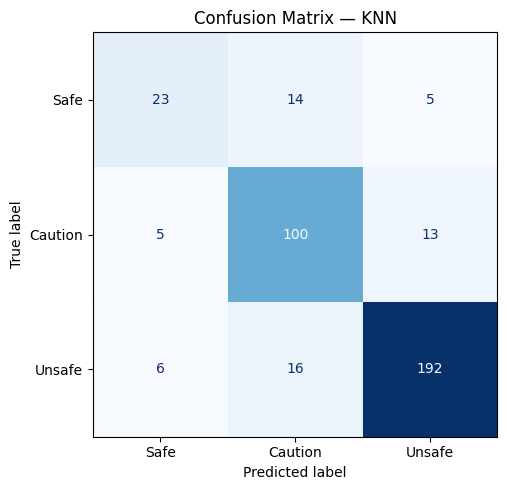

In [12]:
cm = confusion_matrix(y_test, y_pred, labels=present)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[SAFETY_LABELS[i] for i in present]
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — KNN')
plt.tight_layout()
plt.show()

In [13]:
y_prob = best_knn.predict_proba(X_te_s)
y_bin  = label_binarize(y_test, classes=list(range(len(SAFETY_LABELS))))
if y_bin.shape[1] > 1:
    auc = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='weighted')
    print(f'KNN — Weighted OvR ROC-AUC: {auc:.4f}')

KNN — Weighted OvR ROC-AUC: 0.9184


In [14]:
# KNN has no training iterations or epochs — it is a lazy learner that memorises
# the training set and defers all computation to prediction time.
#
# The equivalent question is: how many reference points does it consult,
# and how far are they?

print('=== KNN — Training-Phase Summary ===')
print(f'  Algorithm          : {best_knn.algorithm}  (auto-selected)')
print(f'  Best k             : {best_knn.n_neighbors}')
print(f'  Weighting scheme   : {best_knn.weights}')
print(f'  Distance metric    : {best_knn.metric}')
print(f'  Reference points   : {best_knn.n_samples_fit_}  (entire training set)')
print(f'  Features per point : {best_knn.n_features_in_}')
print()
print('=== Prediction-Time Nearest-Neighbour Distances (first 5 test samples) ===')
distances, indices = best_knn.kneighbors(X_te_s[:5])
for i, (dists, idxs) in enumerate(zip(distances, indices)):
    true_cls  = SAFETY_LABELS[y_test[i]]
    pred_cls  = SAFETY_LABELS[y_pred[i]]
    nbr_cls   = [SAFETY_LABELS[y_train[j]] for j in idxs]
    print(f'  Sample {i+1}  true={true_cls:7s}  pred={pred_cls:7s}')
    print(f'    neighbours : {nbr_cls}')
    print(f'    distances  : {[round(d, 4) for d in dists]}')

=== KNN — Training-Phase Summary ===
  Algorithm          : auto  (auto-selected)
  Best k             : 3
  Weighting scheme   : distance
  Distance metric    : manhattan
  Reference points   : 1492  (entire training set)
  Features per point : 16

=== Prediction-Time Nearest-Neighbour Distances (first 5 test samples) ===
  Sample 1  true=Caution  pred=Caution
    neighbours : ['Caution', 'Caution', 'Caution']
    distances  : [np.float64(1.6325), np.float64(2.8711), np.float64(3.7668)]
  Sample 2  true=Caution  pred=Unsafe 
    neighbours : ['Unsafe', 'Caution', 'Unsafe']
    distances  : [np.float64(1.6348), np.float64(1.9425), np.float64(2.1714)]
  Sample 3  true=Unsafe   pred=Unsafe 
    neighbours : ['Unsafe', 'Unsafe', 'Unsafe']
    distances  : [np.float64(3.1075), np.float64(4.8065), np.float64(5.7846)]
  Sample 4  true=Unsafe   pred=Unsafe 
    neighbours : ['Unsafe', 'Unsafe', 'Unsafe']
    distances  : [np.float64(2.9438), np.float64(3.1019), np.float64(3.1347)]
  Sample 5 